# Training using REINFORCE

## Install dependencies

This notebook tests the InvertedPendulum environment. This environment is based on the Mujoco library. Mujoco is a library for the physics simulation of multibody systems such as robots. It contains a simulation and a visualization engine.
The visualization engine works with OpenGL, a hardware accelerated library to render 3D graphics.

Unfortunately, OpenGL does not play very nice with the Google Colab environment, as this is defined as a headless system (a system without a screen), and OpenGL usually renders its ouputs to a screen.

For this reason the installation is more complex than in other cases.

In [1]:
# First we install mujoco and gymnasium including the mujoco environments
!pip install mujoco
!pip install gymnasium[mujoco]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.4/243.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 25.8 MB/s eta 0:00:00


## Check if installation was successful

In this case, we are going to test that the installation is correct and that we are running using a GPU.

In [2]:
from google.colab import files

import distutils.util
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


## Helper functions

In [3]:
import cv2
import matplotlib.pyplot as plt

# Check if we running in Google Colab or Jupyter Notebook
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Do you need to connect with Google Drive? Uncomment the next two lines
    # from google.colab import drive
    # drive.mount('/content/drive')
    # This auxiliary function simplifies the visualization of OpenCV Images
    from google.colab.patches import cv2_imshow
else:
    print('Running in Jupyter Notebook')
    # This auxiliary function simplifies the visualization of OpenCV Images
    def cv2_imshow(img, title=''):
        if img.ndim > 2:
            img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img)
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()
        else:
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img, cmap='gray')
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()

# Helper functions to save videos and images
def save_video(img_array, path='/content/test.mp4'):
  height, width, layers = img_array[0].shape
  size = (width, height)
  out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MP4V'), 15, size)
  if out.isOpened():
    for i in range(len(img_array)):
      bgr_img = cv2.cvtColor(img_array[i], cv2.COLOR_RGB2BGR)
      out.write(bgr_img)
    out.release()
    print('Video saved.')
  else:
    print(f'Could not save video path: {path}')

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def to_html_video(img_array):
  # Function to update each frame in the animation
  def update_frame(i):
      frame.set_data(img_array[i])
      return frame,

  # Set up the plot
  # Your list of images
  # images = [img1, img2, img3, ...]
  # Assuming all images have the same shape as the first image
  img_height, img_width = img_array[0].shape[:2]

  # Set up the figure size based on the image size with a desired DPI
  dpi = 100
  fig_width = img_width / float(dpi)
  fig_height = img_height / float(dpi)
  fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
  ax.axis('off')

  frame = ax.imshow(img_array[0])

  # Create an animation
  ani = FuncAnimation(fig, update_frame, frames=len(img_array), blit=True)

  # To display the animation inline, convert it to HTML and display it
  html = HTML(ani.to_html5_video())
  plt.close(fig)
  return html

Running in Google Colab



# Training using REINFORCE

Based on: https://gymnasium.farama.org/tutorials/training_agents/reinforce_invpend_gym_v26/ by Siddarth Chandrasekar

<img src="https://gymnasium.farama.org/_images/reinforce_invpend_gym_v26_fig1.gif" width="400" alt="agent-environment-diagram">

This tutorial serves 2 purposes:
 1. To understand how to implement REINFORCE [1] from scratch to solve Mujoco's InvertedPendulum-v4
 2. Implementation a deep reinforcement learning algorithm with Gymnasium's v0.26+ `step()` function

We will be using **REINFORCE**, one of the earliest policy gradient methods. Unlike going under the burden of learning a value function first and then deriving a policy out of it,
REINFORCE optimizes the policy directly. In other words, it is trained to maximize the probability of Monte-Carlo returns. More on that later.

## The Inverted Pendulum environment

**Inverted Pendulum** is Mujoco's cartpole but now powered by the Mujoco physics simulator -
which allows more complex experiments (such as varying the effects of gravity).
This environment involves a cart that can moved linearly, with a pole fixed on it at one end and having another end free.
The cart can be pushed left or right, and the goal is to balance the pole on the top of the cart by applying forces on the cart.
More information on the environment could be found at https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/

**Training Objectives**: To balance the pole (inverted pendulum) on top of the cart

**Actions**: The agent takes a 1D vector for actions. The action space is a continuous ``(action)`` in ``[-3, 3]``,
where action represents the numerical force applied to the cart
(with magnitude representing the amount of force and sign representing the direction)

**Approach**: We use PyTorch to code REINFORCE from scratch to train a Neural Network policy to master Inverted Pendulum.

An explanation of the Gymnasium v0.26+ `Env.step()` function

``env.step(A)`` allows us to take an action 'A' in the current environment 'env'. The environment then executes the action
and returns five variables:

-  ``next_obs``: This is the observation that the agent will receive after taking the action.
-  ``reward``: This is the reward that the agent will receive after taking the action.
-  ``terminated``: This is a boolean variable that indicates whether or not the environment has terminated.
-  ``truncated``: This is a boolean variable that also indicates whether the episode ended by early truncation, i.e., a time limit is reached.
-  ``info``: This is a dictionary that might contain additional information about the environment.


In [4]:
import random

import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.distributions.normal import Normal

import gymnasium as gym

print(f"OpenAI Gym version: {gym.__version__}")
print(f'PyTorch version {torch.__version__}')

plt.rcParams["figure.figsize"] = (10, 5)

OpenAI Gym version: 1.0.0
PyTorch version 2.5.1+cu121


## Policy Network

<img src="https://gymnasium.farama.org/_images/reinforce_invpend_gym_v26_fig2.png">

We start by building a policy that the agent will learn using REINFORCE.
A policy is a mapping from the current environment observation to a probability distribution of the actions to be taken.
The policy used in the tutorial is parameterized by a neural network. It consists of 2 linear layers that are shared between both the predicted mean and standard deviation.
Further, the single individual linear layers are used to estimate the mean and the standard deviation. ``nn.Tanh`` is used as a non-linearity between the hidden layers.
The following function estimates a mean and standard deviation of a normal distribution from which an action is sampled. Hence it is expected for the policy to learn
appropriate weights to output means and standard deviation based on the current observation.



In [5]:
class Policy_Network(nn.Module):
    """Parametrized Policy Network."""

    def __init__(self, state_size: int, action_size: int):
        """Initializes a neural network that estimates the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            state_size: Dimension of the observation space
            action_size: Dimension of the action space
        """
        super().__init__()

        hidden_space1 = 16  # Nothing special with 16, feel free to change
        hidden_space2 = 32  # Nothing special with 32, feel free to change

        # Shared Network
        self.shared_net = nn.Sequential(
            nn.Linear(state_size, hidden_space1),
            nn.Tanh(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.Tanh(),
        )

        # Policy Mean specific Linear Layer
        self.policy_mean_net = nn.Sequential(
            nn.Linear(hidden_space2, action_size)
        )

        # Policy Std Dev specific Linear Layer
        self.policy_stddev_net = nn.Sequential(
            nn.Linear(hidden_space2, action_size)
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Conditioned on the observation, returns the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            x: Observation from the environment

        Returns:
            action_means: predicted mean of the normal distribution
            action_stddevs: predicted standard deviation of the normal distribution
        """
        shared_features = self.shared_net(x.float())

        action_means = self.policy_mean_net(shared_features)
        action_stddevs = torch.log(
            1 + torch.exp(self.policy_stddev_net(shared_features))
        )

        return action_means, action_stddevs

## Building an agent

<img src="https://gymnasium.farama.org/_images/reinforce_invpend_gym_v26_fig3.jpeg">

Now that we are done building the policy, let us develop **REINFORCE** which gives life to the policy network.
The algorithm of REINFORCE could be found above. As mentioned before, REINFORCE aims to maximize the Monte-Carlo returns.

Fun Fact: REINFORCE is an acronym for " 'RE'ward 'I'ncrement 'N'on-negative 'F'actor times 'O'ffset 'R'einforcement times 'C'haracteristic 'E'ligibility

Note: The choice of hyperparameters is to train a decently performing agent. No extensive hyperparameter
tuning was done.




In [6]:
class REINFORCE:
    """REINFORCE algorithm."""

    def __init__(self, state_size: int, action_size: int):
        """Initializes an agent that learns a policy via REINFORCE algorithm [1]
        to solve the task at hand (Inverted Pendulum v4).

        Args:
            state_size: Dimension of the observation space
            action_size: Dimension of the action space
        """

        # Hyperparameters
        self.learning_rate = 1e-4  # Learning rate for policy optimization
        self.gamma = 0.99  # Discount factor
        self.eps = 1e-6  # small number for mathematical stability

        self.probs = []  # Stores probability values of the sampled action
        self.rewards = []  # Stores the corresponding rewards

        self.net = Policy_Network(state_size, action_size)
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)

    def select_action(self, state: np.ndarray) -> float:
        """Returns an action, conditioned on the policy and observation.

        Args:
            state: Observation from the environment

        Returns:
            action: Action to be performed
        """
        state = torch.tensor(np.array([state]))
        action_means, action_stddevs = self.net(state)

        # create a normal distribution from the predicted
        #   mean and standard deviation and sample an action
        distrib = Normal(action_means[0] + self.eps, action_stddevs[0] + self.eps)
        action = distrib.sample()
        prob = distrib.log_prob(action)

        action = action.numpy()

        self.probs.append(prob)

        return action

    def update(self):
        """Updates the policy network's weights."""
        running_g = 0
        gs = []

        # Discounted return (backwards) - [::-1] will return an array in reverse
        for R in self.rewards[::-1]:
            running_g = R + self.gamma * running_g
            gs.insert(0, running_g)

        deltas = torch.tensor(gs)

        loss = 0
        # minimize -1 * prob * reward obtained
        for log_prob, delta in zip(self.probs, deltas):
            loss += log_prob.mean() * delta * (-1)

        # Update the policy network
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Empty / zero out all episode-centric/related variables
        self.probs = []
        self.rewards = []

Now lets train the policy using REINFORCE to master the task of Inverted Pendulum.

Following is the overview of the training procedure

>    for seed in random seeds
>       reinitialize agent
>
>       for episode in range of max number of episodes
>           until episode is done
>               sample action based on current observation
>
>               take action and receive reward and next observation
>
>               store action take, its probability, and the observed reward
>           update the policy


In [7]:
# Create and wrap the environment
env = gym.make("InvertedPendulum-v4", render_mode="rgb_array")
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env, 50)  # Records episode-reward

# Total number of episodes
TOTAL_NUM_EPISODES = 5_000

# Observation-space of Pendulum-v1 (3)
state_size = env.observation_space.shape[0]

# Action-space of Pendulum-v1 (1)
action_size = env.action_space.shape[0]

SEED = 42

# set seed
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Reinitialize agent every seed
agent = REINFORCE(state_size, action_size)
reward_over_episodes = []

for episode in tqdm(range(TOTAL_NUM_EPISODES)):
    # gymnasium v26 requires users to set seed while resetting the environment
    obs, info = wrapped_env.reset(seed=SEED)

    done = False
    while not done:
        action = agent.select_action(obs)

        # Step return type - `tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]`
        # These represent the next observation, the reward from the step,
        # if the episode is terminated, if the episode is truncated and
        # additional info from the step
        obs, reward, terminated, truncated, info = wrapped_env.step(action)
        agent.rewards.append(reward)

        # End the episode when either truncated or terminated is true
        #  - truncated: The episode duration reaches max number of timesteps
        #  - terminated: Any of the state space values is no longer finite.
        done = terminated or truncated

    reward_over_episodes.append(wrapped_env.return_queue[-1])
    agent.update()


/usr/local/lib/python3.10/dist-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


  0%|          | 0/5000 [00:00<?, ?it/s]

## Plot learning curve




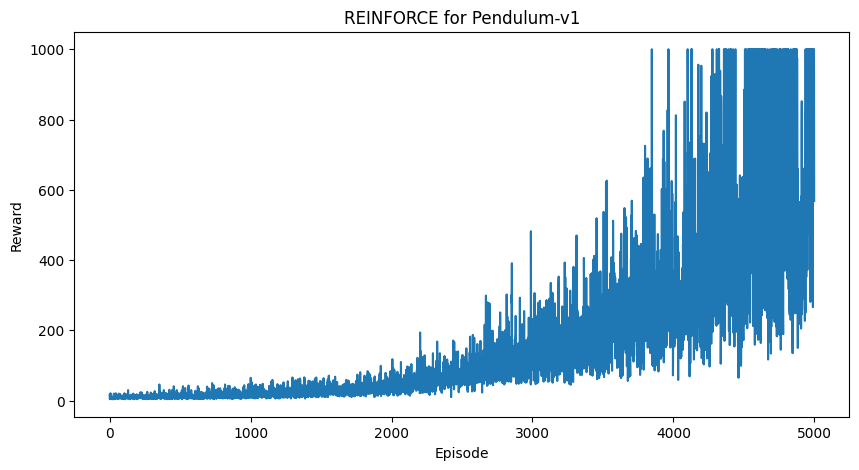

In [8]:
x = np.arange(len(reward_over_episodes))
# Plot the values
plt.plot(x, reward_over_episodes)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('REINFORCE for Pendulum-v1')
plt.show()

## Test the agent

In [9]:
done = False

img_array=[]

wrapped_env.reset()

while not done:
    with torch.no_grad():
        action = agent.select_action(obs)

    obs, reward, terminated, truncated, info = wrapped_env.step(action)
    frame = wrapped_env.render()
    img_array.append(frame)

    done = terminated or truncated

#save_video(img_array, path='/content/REINFORCE_pendulum.mp4')
to_html_video(img_array)


## Notes

Deep RL is fairly brittle concerning random seed in a lot of common use cases (https://spinningup.openai.com/en/latest/spinningup/spinningup.html).

## Exercise

- Analyse the iterations per second during training. What happens? Why? What would happen if at some point we find the perfect agent?
- Compare the convergence rate depending on different seeds.


## References

[1] Williams, Ronald J.. “Simple statistical gradient-following
algorithms for connectionist reinforcement learning.” Machine Learning 8
(2004): 229-256.


